In [1]:
# Подключенине библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import data_processing as dp
import custom_modules.PipeData as pidf

from matplotlib import ticker
from IPython.display import display
from tensorflow import keras

In [2]:
# paths for files with original data
PATH_TO_DATA = {
    'run_1': 
        ('data/Original data/Run1/run1_WM32_data.csv',
        'data/Original data/Run1/run1_WM32_defects.csv',
        'data/Original data/Run1/run1_WM32_pipe.csv'),
    'run_2':
        ('data/Original data/Run2/run2_WM32_data.csv',
        'data/Original data/Run2/run2_WM32_defects.csv',
        'data/Original data/Run2/run2_WM32_pipe.csv')
}

CROP_SIZE = 64
CROP_STEP = 20

# детерминация случайных величин, отвечающих за выбор первоначальных весов и биасов
tf.compat.v1.set_random_seed(290)
tf.random.set_seed(290)

# чтение данных
test_1 = pidf.PipeDataCsvWorker(*PATH_TO_DATA['run_2'])

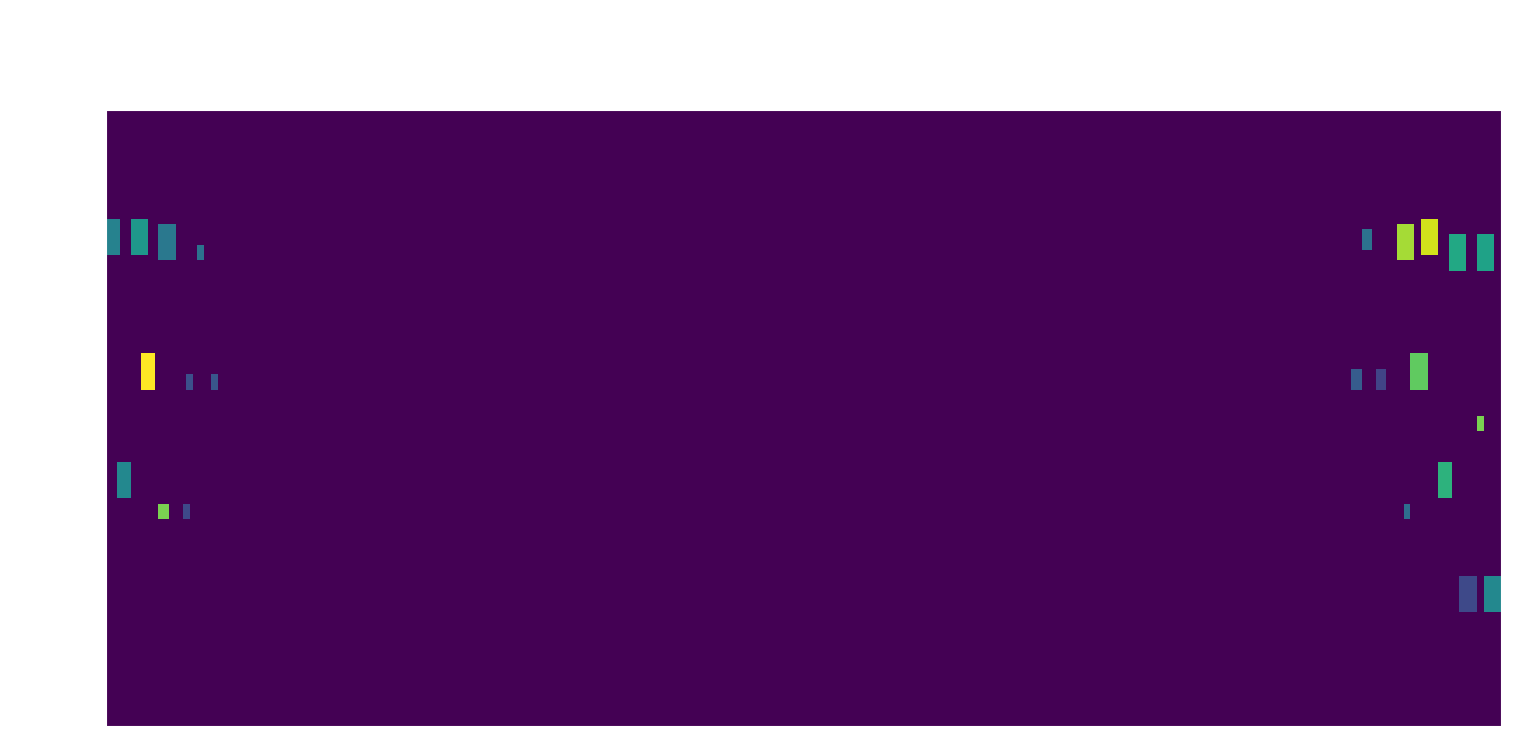

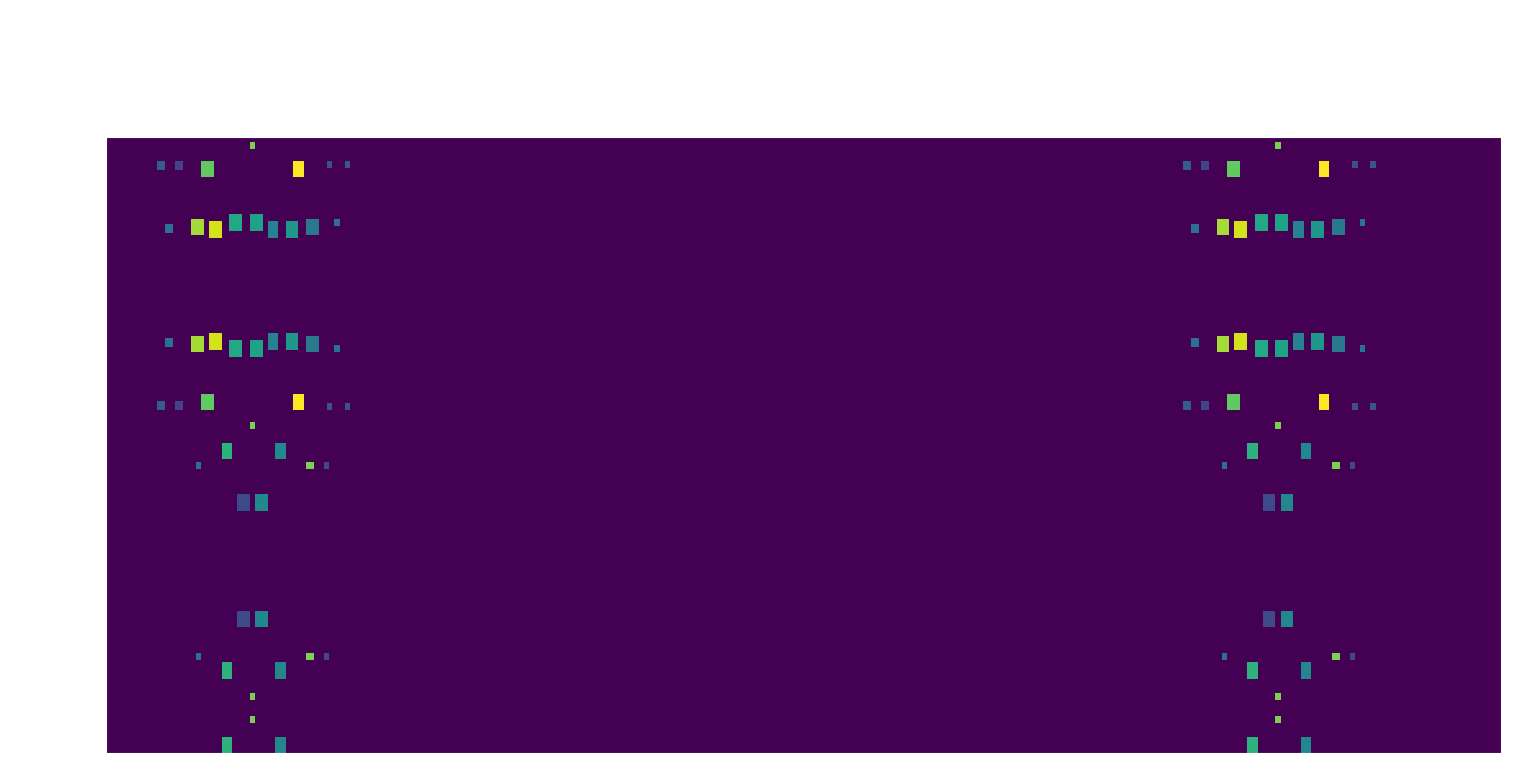

In [3]:
# Вывод считанных данных и их расширение для обучения
test_1.draw_defects_map(title='Считанная развернутая карта дефектов')

ORIG_df_cols = test_1.get_data_df().shape[1]
ORIG_df_rows = test_1.get_data_df().shape[0]

test_1.extend_dfs_for_prediction(crop_size=CROP_SIZE, crop_step=CROP_STEP)

# Запишем размеры датафреймов после обработки
PREP_df_cols = test_1.get_data_df().shape[1]
PREP_df_rows = test_1.get_data_df().shape[0]

test_1.draw_defects_map(title=f'Расширенная развернутая карта дефектов для cr.size: {CROP_SIZE} и cr.step: {CROP_STEP}')

In [4]:
# Запишем размеры датафреймов до обработки
# Забрать данные из класса
x_data = test_1.get_data_df()
y_data = test_1.get_defects_df()
test_1 = None

In [5]:
# Загрузка модели
model = keras.models.load_model('Networks//CNN//NetWork_(64x64+64x64)_to(4x4)_(test_0dot0)_ver_11.h5')

In [6]:
# нормализация значений массива
def normalize_data(arr): 
    return  arr / arr.max()

In [7]:
# Преобразовать массив результатов работы модели размера (batch,1)
# в матрицу размера PREP_df_rows * PREP_df_cols (карту дефектов, построенную моделью)
# Размер выходной матрицы - PREP_df_rows * PREP_df_cols
# Так как начальное расширение датафрейма на PREP_image_size по 2 осям
# тут учитывается грубо, то размер выходной матрицы будет также
# PREP_df_rows * PREP_df_cols, а ячейки по конрутру будут размыты 
# и не точны, так как по ним фильтр прошел меньше раз чем по ячейкам 
# посреди матрицы

# y = x + k
def draw_prediction_map_2_0(model, df, orig_rows_count, orig_cols_count,
                                    result_rows_count, result_cols_count, 
                                    crop_size, step = -1):

    print('||||||||||||||||||')
    print('draw_prediction_map_2_0')
    print('Crop windows height/width: ', crop_size)
    print('Crop windows step across rows and cols: ', step)

    if step == -1:
        step = crop_size
    
    new_arr = np.ones((result_rows_count, result_cols_count))     

    center = crop_size // 2 
    
    for i in range(0, result_rows_count - crop_size + 1, step): 
        print(f'row: {i} of {result_rows_count}')
        for j in range(0, result_cols_count - crop_size + 1, step):
            temp_crop = dp.pandas_crop_to_image_like_numpy(df.iloc[i:i+crop_size,j:j+crop_size])
            temp_crop = np.expand_dims(temp_crop, axis=0)
            temp_crop = normalize_data(temp_crop)
            res = model.predict([temp_crop[:,:,:,:32], temp_crop[:,:,:,32:]])

            # left top 
            if res[0,0,0] >= 0.5:
                new_arr[i:i+crop_size,j:j+crop_size][:center,:center] += res[0,0,0]
            else:
                new_arr[i:i+crop_size,j:j+crop_size][:center,:center] -= res[0,0,0]

            # right top
            if res[0,0,1] >= 0.5:
                new_arr[i:i+crop_size,j:j+crop_size][:center,center:] += res[0,0,1]
            else:
                new_arr[i:i+crop_size,j:j+crop_size][:center,center:] -= res[0,0,1]

            # left bottom
            if res[0,1,0] >= 0.5:
                new_arr[i:i+crop_size,j:j+crop_size][center:,:center] += res[0,1,0]
            else:
                new_arr[i:i+crop_size,j:j+crop_size][center:,:center] -= res[0,1,0]

            # right bottom
            if res[0,1,1] >= 0.5:
                new_arr[i:i+crop_size,j:j+crop_size][center:,center:] += res[0,1,1]
            else:
                new_arr[i:i+crop_size,j:j+crop_size][center:,center:] -= res[0,1,1]
    

    left_up_border = crop_size - 1
    right_border = result_cols_count - (result_cols_count - orig_cols_count) + 1
    bottom_border = result_rows_count - (result_rows_count - orig_rows_count) + 1
    
    print('New numpy shape: ', new_arr.shape)
    print('||||||||||||||||||\n')
    
    return new_arr, new_arr[left_up_border:,left_up_border:][:orig_rows_count,:orig_cols_count]

In [8]:
map_0, map_2 = draw_prediction_map_2_0(model, x_data,
                                   ORIG_df_rows, ORIG_df_cols,
                                   PREP_df_rows, PREP_df_cols, 
                                   CROP_SIZE, CROP_STEP)

||||||||||||||||||
draw_prediction_map_2_0
Crop windows height/width:  64
Crop windows step across rows and cols:  20
row: 0 of 264
1/1 [==============================] - 0s 403ms/step
row: 20 of 264
1/1 [==============================] - 0s 363ms/step
row: 40 of 264
1/1 [==============================] - 0s 369ms/step
row: 60 of 264
1/1 [==============================] - 0s 344ms/step
row: 80 of 264
1/1 [==============================] - 0s 315ms/step
row: 100 of 264
1/1 [==============================] - 0s 379ms/step
row: 120 of 264
1/1 [==============================] - 0s 404ms/step
row: 140 of 264
1/1 [==============================] - 0s 409ms/step
row: 160 of 264
1/1 [==============================] - 0s 447ms/step
row: 180 of 264
1/1 [==============================] - 1s 507ms/step
row: 200 of 264
1/1 [==============================] - 0s 427ms/step
New numpy shape:  (264, 544)
||||||||||||||||||



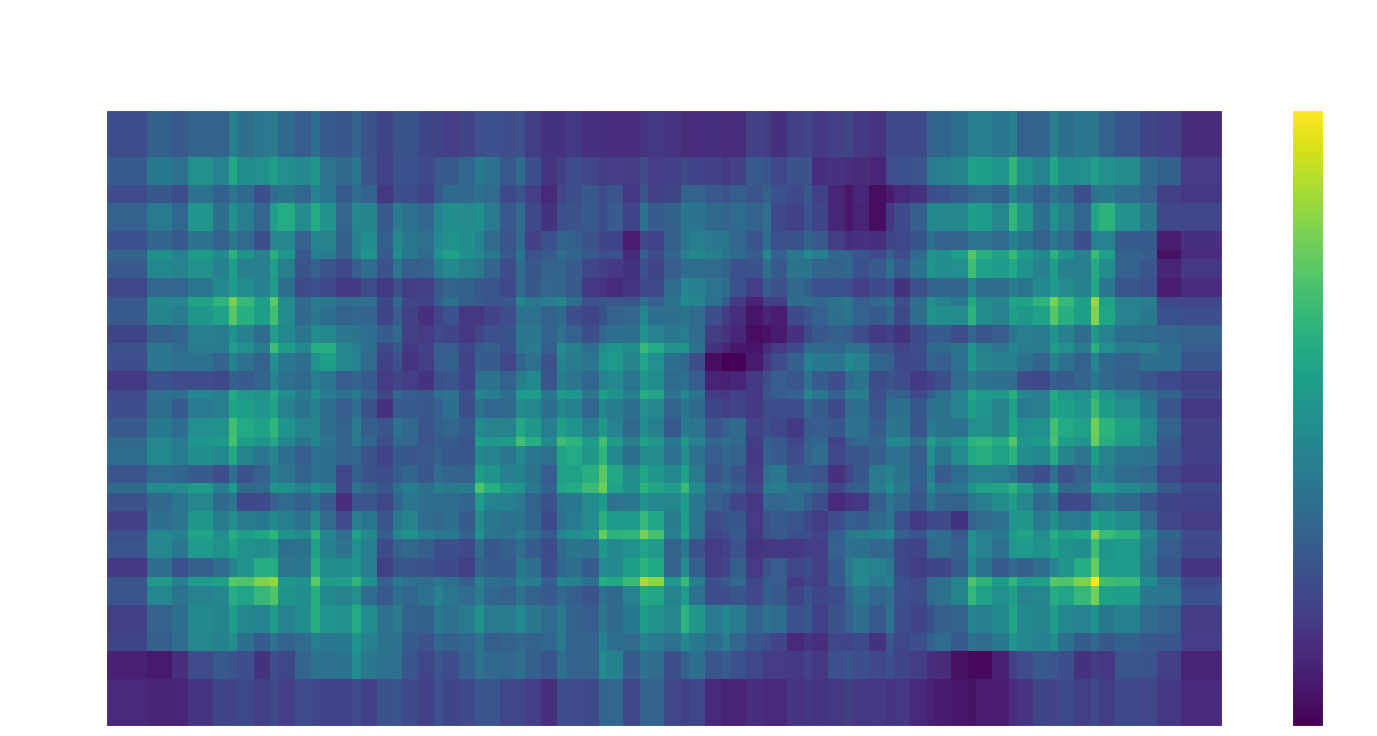

In [9]:
with plt.style.context('dark_background'):
            fig, ax = plt.subplots()
        
            fig.set_figwidth(18)
            fig.set_figheight(8)
            fig.patch.set_alpha(0.0)
        
            ax.invert_yaxis()
            ax.xaxis.tick_top()
            ax.xaxis.set_label_position('top')
            ax.set_title("Предсказанная развернутая карта дефектов", fontsize=25)
            ax.set_xlabel('Номер датчика', fontsize=20)
            ax.set_ylabel('Номер измерения', fontsize=20)
            ax.tick_params(axis='both', labelsize = 20)

            map = ax.pcolormesh(map_0)
            cbar = fig.colorbar(map)
            cbar.ax.tick_params(labelsize=20)

            ax.xaxis.set_major_locator(ticker.MultipleLocator(60))
    
plt.show()

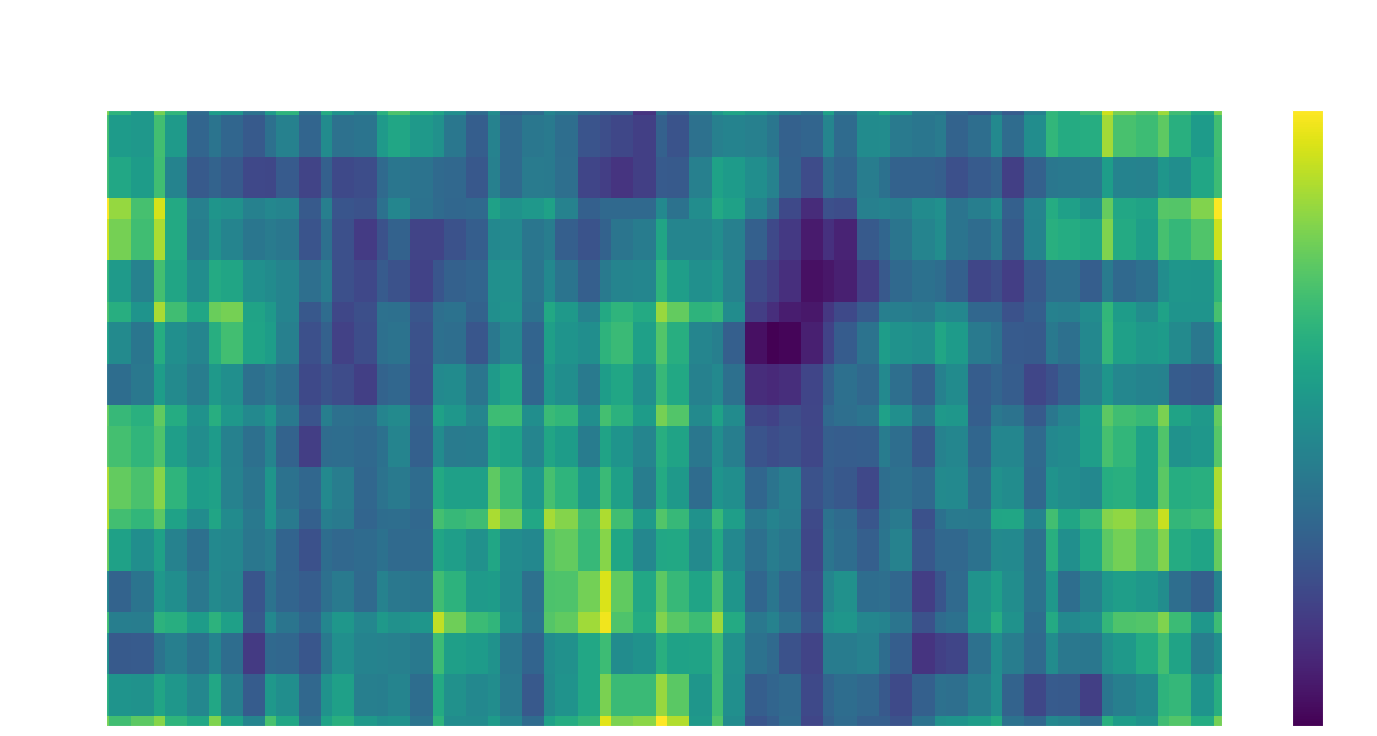

In [10]:
with plt.style.context('dark_background'):
            fig, ax = plt.subplots()
        
            fig.set_figwidth(18)
            fig.set_figheight(8)
            fig.patch.set_alpha(0.0)
        
            ax.invert_yaxis()
            ax.xaxis.tick_top()
            ax.xaxis.set_label_position('top')
            ax.set_title("Предсказанная развернутая карта дефектов", fontsize=25)
            ax.set_xlabel('Номер датчика', fontsize=20)
            ax.set_ylabel('Номер измерения', fontsize=20)
            ax.tick_params(axis='both', labelsize = 20)

            map = ax.pcolormesh(map_2)
            cbar = fig.colorbar(map)
            cbar.ax.tick_params(labelsize=20)

            ax.xaxis.set_major_locator(ticker.MultipleLocator(60))
    
plt.show()